1. Import the dataset

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import pickle

In [36]:
df = pd.read_csv("../dataset/Churn_Modelling.csv")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [37]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


In [38]:
target_col = df['Exited']
df = df.drop(['RowNumber', 'CustomerId', 'Surname', 'Exited'], axis = 1)
ct = ColumnTransformer(
    transformers=[
            ('encoder', OneHotEncoder(sparse_output=False), ['Gender', 'Geography'])
        ],
    remainder='passthrough'
).set_output(transform = 'pandas')

df = ct.fit_transform(df)
df = pd.concat([df, target_col], axis=1)

# from sklearn.preprocessing import OneHotEncoder
# ohe = OneHotEncoder(sparse_output=False).set_output(transform='pandas')
# df = ohe.fit_transform(df[['Geography', 'Gender']])

In [6]:
df.head

<bound method NDFrame.head of       encoder__Gender_Female  encoder__Gender_Male  encoder__Geography_France  \
0                        1.0                   0.0                        1.0   
1                        1.0                   0.0                        0.0   
2                        1.0                   0.0                        1.0   
3                        1.0                   0.0                        1.0   
4                        1.0                   0.0                        0.0   
...                      ...                   ...                        ...   
9995                     0.0                   1.0                        1.0   
9996                     0.0                   1.0                        1.0   
9997                     1.0                   0.0                        1.0   
9998                     0.0                   1.0                        0.0   
9999                     1.0                   0.0                        1.0  

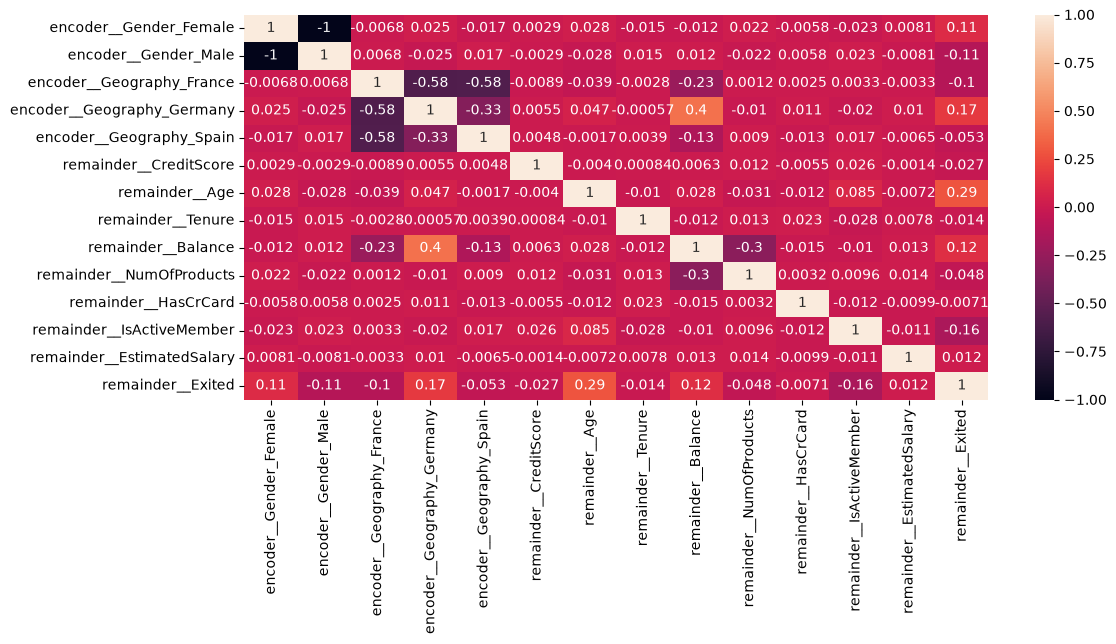

In [7]:
plt.figure(figsize=(12, 5))
sns.heatmap(df.corr(), annot=True)
plt.show()

In [39]:
#save the preprocess model
with open("column_transformer.pkl", 'wb') as f:
    pickle.dump(ct, f) 

In [9]:
#splitting the data
X = df.drop('remainder__Exited', axis=1)
y = df['remainder__Exited']
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42)

standard_scaler = StandardScaler()
X_train = standard_scaler.fit_transform(X_train)
X_test = standard_scaler.transform(X_test)

In [10]:
with open('standard_scaler.pkl', 'wb') as f:
    pickle.dump(standard_scaler, f)

# ANN Implementation

+ Cell 1: Environment and Tool Setup

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.tensorboard import SummaryWriter
import datetime



- Cell 2: Data Pipeline

In [12]:
# Convert Numpy arrays to PyTorch Tensors
X_train_tensor = torch.FloatTensor(X_train)
# .view(-1, 1) ensures the target is a 2D column vector, which BCELoss requires
y_train_tensor = torch.FloatTensor(y_train.values).view(-1, 1) 
X_val_tensor = torch.FloatTensor(X_test)
y_val_tensor = torch.FloatTensor(y_test.values).view(-1, 1)

C:\Users\rajes\AppData\Local\Temp\ipykernel_5824\4229262660.py:4: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  y_train_tensor = torch.FloatTensor(y_train.values).view(-1, 1)


- Cell 3: Model Architecture

In [13]:
class BinaryClassificationModel(nn.Module):
    def __init__(self, input_size):
        super(BinaryClassificationModel, self).__init__()
        self.layer1 = nn.Linear(input_size, 64)
        self.relu1 = nn.ReLU()
        self.layer2 = nn.Linear(64, 32)
        self.relu2 = nn.ReLU()
        self.output_layer = nn.Linear(32, 1)
        self.sigmoid= nn.Sigmoid()

    def forward(self, x):
        x = self.relu1(self.layer1(x))
        x = self.relu2(self.layer2(x))
        x = self.sigmoid(self.output_layer(x))
        return x

In [14]:
X_train.shape

(8000, 13)

- Cell 4: Initialization & Configuration

In [15]:
input_size = X_train.shape[1]
# Check for GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on: {device}")

# Move the model to the GPU
model = BinaryClassificationModel(input_size).to(device)

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

#Logging and early stopping setup
log_dir = 'logs/fit/' + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
writer = SummaryWriter(log_dir)

patience = 10
best_val_loss = float('inf')
epochs_no_imporve = 0
best_model_weights = None

Training on: cuda


- Cell 5: The training Engine

In [16]:
# 5. The Custom Training Loop (Replacing model.fit)
num_epochs = 100

for epoch in range(num_epochs):
    
    # --- TRAINING PHASE ---
    model.train() # Tell PyTorch you are in training mode
    
    # Forward pass: pass the data through the network
    outputs = model(X_train_tensor.to(device))
    loss = criterion(outputs, y_train_tensor.to(device))
    
    # Backward pass and optimization
    optimizer.zero_grad() # 1. Clear old gradients from the previous step
    loss.backward()       # 2. Backpropagation: compute new gradients
    optimizer.step()      # 3. Update the weights
    
    # --- VALIDATION PHASE ---
    model.eval() # Tell PyTorch you are evaluating (disables things like dropout if you had it)
    with torch.no_grad(): # Disable gradient calculation for validation to save memory
        val_outputs = model(X_val_tensor.to(device))
        val_loss = criterion(val_outputs, y_val_tensor.to(device))
        
        # Calculate Validation Accuracy
        predicted_classes = (val_outputs >= 0.5).float()
        correct_predictions = (predicted_classes == y_val_tensor.to(device)).sum().item()
        val_accuracy = correct_predictions / y_val_tensor.size(0)

    # Log metrics to TensorBoard
    writer.add_scalar('Loss/train', loss.item(), epoch)
    writer.add_scalar('Loss/validation', val_loss.item(), epoch)
    writer.add_scalar('Accuracy/validation', val_accuracy, epoch)

    # --- EARLY STOPPING CHECK ---
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        best_model_weights = model.state_dict() # Save the exact weights of this best epoch
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping triggered at epoch {epoch}. Restoring best weights.")
            model.load_state_dict(best_model_weights) # Restore the best weights
            break

    # Print progress every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {loss.item():.4f}, Val Loss: {val_loss.item():.4f}')



Epoch [10/100], Train Loss: 0.4465, Val Loss: 0.4314
Epoch [20/100], Train Loss: 0.4231, Val Loss: 0.4049
Epoch [30/100], Train Loss: 0.4087, Val Loss: 0.3937
Epoch [40/100], Train Loss: 0.3837, Val Loss: 0.3713
Epoch [50/100], Train Loss: 0.3529, Val Loss: 0.3546
Epoch [60/100], Train Loss: 0.3356, Val Loss: 0.3498
Epoch [70/100], Train Loss: 0.3255, Val Loss: 0.3462
Epoch [80/100], Train Loss: 0.3161, Val Loss: 0.3395
Epoch [90/100], Train Loss: 0.3075, Val Loss: 0.3390
Early stopping triggered at epoch 96. Restoring best weights.


In [17]:
%load_ext tensorboard

In [18]:
%tensorboard --logdir logs/fit/20260903-183043

ERROR: Failed to launch TensorBoard (exited with 1).

- Cell 6: Export

In [19]:
# Close the TensorBoard writer
writer.close()
torch.save(model.state_dict(), 'model.pth')
print("Model saved successfully.")

Model saved successfully.


In [19]:
df.columns

Index(['encoder__Gender_Female', 'encoder__Gender_Male',
       'encoder__Geography_France', 'encoder__Geography_Germany',
       'encoder__Geography_Spain', 'remainder__CreditScore', 'remainder__Age',
       'remainder__Tenure', 'remainder__Balance', 'remainder__NumOfProducts',
       'remainder__HasCrCard', 'remainder__IsActiveMember',
       'remainder__EstimatedSalary', 'remainder__Exited'],
      dtype='str')

# MODEL Prediction

In [24]:
input_data = {
    'CreditScore': 600, 
    'Geography': 'France',
    'Gender': 'Male', 
    'Age': 40, 
    'Tenure': 3, 
    'Balance': 60000, 
    'NumOfProducts': 2, 
    'HasCrCard': 1,
    'IsActiveMember': 1, 
    'EstimatedSalary': 50000
}

In [49]:
input_data_converted = ct.transform(pd.DataFrame([input_data]))
X_input = torch.FloatTensor(input_data_converted.values)

In [50]:
X_input

tensor([[0.0000e+00, 1.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00, 6.0000e+02,
         4.0000e+01, 3.0000e+00, 6.0000e+04, 2.0000e+00, 1.0000e+00, 1.0000e+00,
         5.0000e+04]])

In [54]:
model.eval()
# 1. Run the prediction without calculating gradients
with torch.no_grad():
    prediction_tensor = model(X_input.to(device))

# 2. Move to CPU and extract the raw float probability (e.g., 0.76)
probability = prediction_tensor.cpu().item()

# 3. Convert probability to a 0 or 1 classification using a 50% threshold
classification = 1 if probability >= 0.5 else 0

# 4. Print clean, readable results
print(f"--- Prediction Results ---")
print(f"Raw Model Output (Tensor): {prediction_tensor}")
print(f"Raw Probability:         {probability}%")
print(f"Churn Probability:         {probability * 100:.2f}%")
print(f"Final Decision:            {'Exited (1)' if classification == 1 else 'Stayed (0)'}")


--- Prediction Results ---
Raw Model Output (Tensor): tensor([[1.]], device='cuda:0')
Raw Probability:         1.0%
Churn Probability:         100.00%
Final Decision:            Exited (1)


tensor([[1.]], device='cuda:0', grad_fn=<SigmoidBackward0>)